# DBSCAN
DBSCAN группирует точки по плотности. Точка является core, если в ее $\varepsilon$-окрестности $N_\varepsilon(x)$ находится как минимум $\text{min\_samples}$ точек. Кластеры формируются из всех точек, достижимых по плотности, а точки, не относящиеся ни к одному кластеру, помечаются как шум. Метод не требует заранее задавать число кластеров и хорошо выделяет плотные области и выбросы.


## Используемые библиотеки
Используем `numpy`, `seaborn`, `matplotlib`. Из `sklearn` — реальный датасет `load_digits`, `StandardScaler`, `PCA`, `DBSCAN`, `silhouette_score`, `adjusted_rand_score`.


In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [2]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120
HEATMAP_CMAP = "coolwarm"


## Датасет: описание и частичная распечатка
Используем реальный датасет **Digits** из `sklearn`, но берём только цифры `0`, `1`, `2`, `3`, чтобы задача оставалась наглядной и быстрой. Каждое изображение — это матрица 8×8, то есть 64 признака. Такой пример реалистичнее синтетических «лун»: точки живут в пространстве пикселей, в данных есть похожие классы и потенциальные выбросы.


In [3]:
digits = load_digits(as_frame=True)
data = digits.frame
data = data[data["target"].isin([0, 1, 2, 3])].reset_index(drop=True)
print(f"Размерность: {data.shape}")
data.head()


Размерность: (720, 65)


,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,1.0,9.0,15.0,11.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,10.0,13.0,3.0,0.0,0.0,0


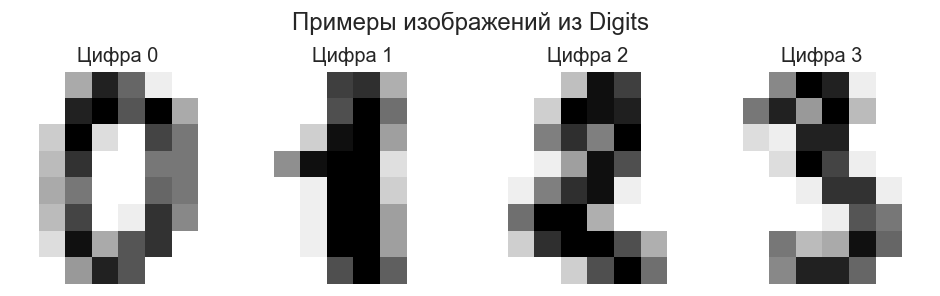

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(8, 2.5))
for ax, digit in zip(axes, [0, 1, 2, 3]):
    sample_image = (
        data.loc[data["target"] == digit]
        .drop(columns=["target"])
        .iloc[0]
        .to_numpy()
        .reshape(8, 8)
    )
    ax.imshow(sample_image, cmap="gray_r")
    ax.set_title(f"Цифра {digit}")
    ax.axis("off")
plt.suptitle("Примеры изображений из Digits")
plt.tight_layout()
plt.show()


## Предварительная обработка
Стандартизируем данные, затем уменьшаем размерность с помощью `PCA`. Для DBSCAN это особенно полезно на реальных изображениях: в высокой размерности расстояния становятся менее информативными, а в PCA-представлении плотностная структура читается лучше. Для кластеризации используем 8 компонент, для графиков — первые две.


In [5]:
features = data.drop(columns=["target"])
target = data["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

pca = PCA(n_components=8, random_state=42)
X_pca = pca.fit_transform(X_scaled)
X_vis = X_pca[:, :2]


## Тепловая карта корреляций
Покажем первые 12 пиксельных признаков. На реальных изображениях пиксели рядом друг с другом обычно коррелируют, поэтому данные заметно сложнее независимых синтетических координат.


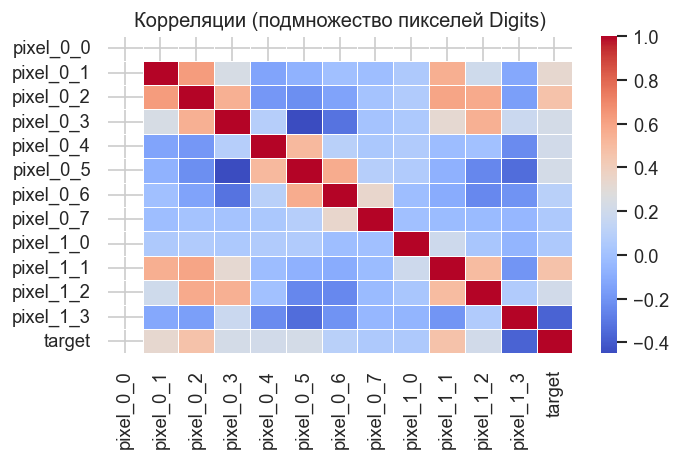

In [6]:
plt.figure(figsize=(6, 4))
subset_cols = list(features.columns[:12])
correlation = data[subset_cols + ["target"]].corr()
sns.heatmap(correlation, annot=False, cmap=HEATMAP_CMAP, linewidths=0.3)
plt.title("Корреляции (подмножество пикселей Digits)")
plt.tight_layout()
plt.show()


## Обучение модели
Кластеризуем данные в PCA-пространстве: `DBSCAN(eps=2.5, min_samples=10)`. Эти параметры подобраны так, чтобы на реальном поднаборе Digits алгоритм находил несколько устойчивых плотных групп и оставлял часть неоднозначных изображений шумом. Метка `-1` означает шум.


In [7]:
model = DBSCAN(eps=2.5, min_samples=10)
model.fit(X_pca)


,eps,2.5
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


## Прогнозы модели
Выводим число найденных кластеров, долю шума и две метрики:
- **Silhouette Score** — считаем только по точкам, не помеченным как шум;
- **Adjusted Rand Index (ARI)** — внешняя метрика согласованности с известными цифрами, только для анализа результата.


In [8]:
labels = model.labels_
cluster_labels = labels[labels >= 0]
noise_ratio = np.mean(labels == -1)

if len(np.unique(cluster_labels)) > 1:
    score = silhouette_score(X_pca[labels >= 0], cluster_labels)
else:
    score = float("nan")

ari = adjusted_rand_score(target, labels)

print("DBSCAN on Digits")
print(f"Clusters: {len(np.unique(cluster_labels))}")
print(f"Noise ratio: {noise_ratio:.3f}")
print(f"Silhouette (без шума): {score:.3f}")
print(f"ARI: {ari:.3f}")


DBSCAN on Digits
Clusters: 4
Noise ratio: 0.122
Silhouette (без шума): 0.394
ARI: 0.742


## Графики выходных результатов
**Scatter-график в пространстве первых двух главных компонент.** Каждый цвет — найденный кластер, шум — чёрный. На реальных изображениях часть точек может выпадать в шум: для DBSCAN это не ошибка, а способ явно отметить неоднозначные или редкие объекты.


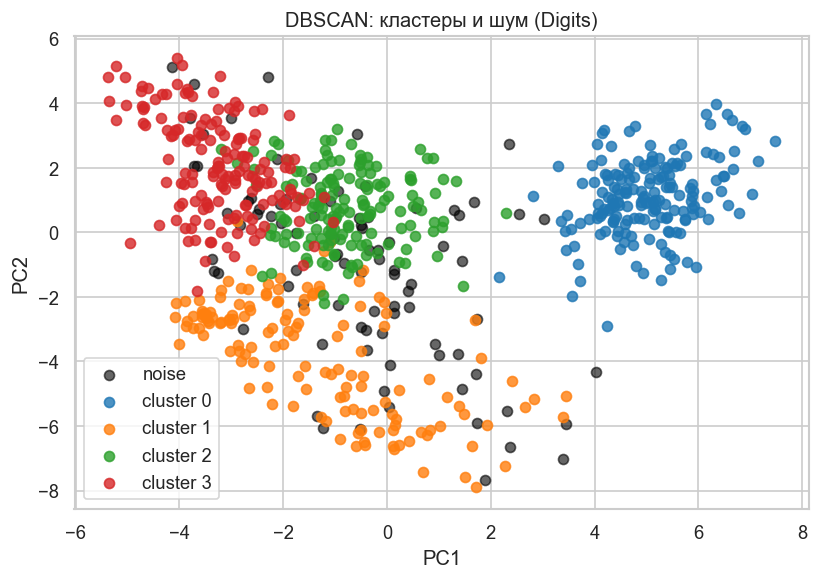

In [9]:
unique_labels = np.unique(labels)
colors = sns.color_palette("tab10", n_colors=max(len(unique_labels) - (1 if -1 in unique_labels else 0), 1))
color_idx = 0

plt.figure(figsize=(7, 5))
for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(
            X_vis[mask, 0],
            X_vis[mask, 1],
            c="black",
            alpha=0.6,
            label="noise",
        )
    else:
        plt.scatter(
            X_vis[mask, 0],
            X_vis[mask, 1],
            color=colors[color_idx],
            alpha=0.8,
            label=f"cluster {label}",
        )
        color_idx += 1

plt.title("DBSCAN: кластеры и шум (Digits)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()
